# 09 — Interpretabilidade dos Modelos

Este notebook corresponde à dimensão de **interpretabilidade** da avaliação multidimensional dos classificadores.

## Objetivos

1. identificar quais variáveis contribuem mais para o desempenho preditivo de cada modelo;
2. comparar a importância das variáveis entre os quatro classificadores;
3. examinar a direção e magnitude dos coeficientes da Regressão Logística;
4. examinar as importâncias internas de Random Forest e Gradient Boosting;
5. produzir análise SHAP para os modelos de árvore, quando a biblioteca estiver disponível;
6. avaliar a convergência entre diferentes métodos de interpretação.

## Regra metodológica

Esta etapa é **pós-avaliação OOT**.

Portanto:

- nenhum modelo será retreinado;
- nenhuma variável será removida;
- nenhum hiperparâmetro será alterado;
- nenhuma regra de threshold ou Top-k será modificada;
- os resultados de interpretabilidade serão utilizados para **explicar** os modelos, e não para reabrir o desenvolvimento.

A interpretação dos atributos representa associações aprendidas pelos modelos e **não deve ser tratada como evidência causal**.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path
import json
import warnings
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42

# A Permutation Importance exige múltiplas novas predições.
# Como o KNN utiliza busca por vizinhos, o cálculo pode ser custoso.
# A amostra abaixo mantém o diagnóstico reproduzível e comparável entre modelos.
N_AMOSTRA_PERMUTACAO = 1500
N_REPETICOES_PERMUTACAO = 5

# SHAP é complementar e pode ser mais custoso.
N_AMOSTRA_SHAP = 500
EXECUTAR_SHAP = True


## 2. Diretórios e verificação das etapas anteriores


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")

PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"
MODELS_DIR = PROJECT_DIR / "outputs" / "modelos"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
CONFIG_DIR = PROJECT_DIR / "outputs" / "config"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"
CONFIG_FILE = CONFIG_DIR / "configuracao_operacional_congelada.json"
OOT_REGISTER_FILE = CONFIG_DIR / "registro_avaliacao_oot.json"

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Configuração operacional congelada não encontrada."
    )

if not OOT_REGISTER_FILE.exists():
    raise FileNotFoundError(
        "Registro da avaliação OOT não encontrado. "
        "Execute primeiro o Script 07."
    )

with CONFIG_FILE.open("r", encoding="utf-8") as f:
    configuracao = json.load(f)

with OOT_REGISTER_FILE.open("r", encoding="utf-8") as f:
    registro_oot = json.load(f)

if registro_oot.get("avaliacao_final_executada") is not True:
    raise RuntimeError(
        "A avaliação OOT ainda não está registrada como concluída."
    )

print("Etapas anteriores confirmadas.")
print(f"Modelos: {configuracao['modelos_para_oot']}")


Etapas anteriores confirmadas.
Modelos: ['Regressão Logística', 'KNN', 'Random Forest', 'Gradient Boosting']


## 3. Carregamento da base OOT


In [3]:
df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

TARGET = "target"

df_oot = (
    df[df["Amostra"] == "OOT"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

if df_oot.empty:
    raise ValueError(
        "A partição OOT está vazia."
    )

print(f"OOT: {len(df_oot):,} registros")
print(
    f"Período: {df_oot['AAAA_MM'].min()} a {df_oot['AAAA_MM'].max()}"
)
print(
    f"Prevalência de Resolvida: {df_oot[TARGET].mean():.4f}"
)


OOT: 32,072 registros
Período: 2025_08 a 2026_07
Prevalência de Resolvida: 0.2853


## 4. Carregamento dos pipelines congelados


In [4]:
MAPA_ARQUIVOS = {
    "Regressão Logística": MODELS_DIR / "modelo_treino_regressao_logistica.joblib",
    "KNN": MODELS_DIR / "modelo_treino_knn.joblib",
    "Random Forest": MODELS_DIR / "modelo_treino_random_forest.joblib",
    "Gradient Boosting": MODELS_DIR / "modelo_treino_gradient_boosting.joblib"
}

nomes_modelos = configuracao["modelos_para_oot"]

modelos = {}

for nome in nomes_modelos:
    caminho = MAPA_ARQUIVOS.get(nome)

    if caminho is None:
        raise KeyError(
            f"Modelo não reconhecido: {nome}"
        )

    if not caminho.exists():
        raise FileNotFoundError(
            f"Pipeline não encontrado: {caminho}"
        )

    modelos[nome] = joblib.load(
        caminho
    )

print("Pipelines carregados:")
for nome in modelos:
    print(f"- {nome}")


Pipelines carregados:
- Regressão Logística
- KNN
- Random Forest
- Gradient Boosting


## 5. Identificação dos atributos utilizados por cada modelo


In [5]:
PREDITORES_PADRAO = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

def obter_features_modelo(modelo):
    for step_name in ["codificacao", "preprocessamento"]:
        if step_name in modelo.named_steps:
            transformador = modelo.named_steps[step_name]

            if hasattr(transformador, "feature_names_in_"):
                return list(
                    transformador.feature_names_in_
                )

    return PREDITORES_PADRAO.copy()


features_por_modelo = {
    nome: obter_features_modelo(modelo)
    for nome, modelo in modelos.items()
}

for nome, features in features_por_modelo.items():
    print(f"{nome}: {len(features)} atributos")
    print(features)
    print()


Regressão Logística: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

KNN: 10 atributos
['Região', 'UF', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Random Forest: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Gradient Boosting: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']



# PARTE A — Permutation Importance

## 6. Construção de uma amostra estratificada do OOT

A Permutation Importance mede a redução do desempenho do modelo após embaralhar uma variável.

Neste estudo, a métrica utilizada será **Average Precision (PR-AUC/AP)**, a mesma empregada na seleção de hiperparâmetros.

Como o cálculo exige várias novas predições — especialmente custosas no KNN — será utilizada uma amostra estratificada e reproduzível do OOT.

Importante: esta amostra é utilizada apenas para **interpretação pós-hoc**, não para desenvolvimento ou seleção de modelos.


In [6]:
n_amostra = min(
    N_AMOSTRA_PERMUTACAO,
    len(df_oot)
)

_, df_perm = train_test_split(
    df_oot,
    test_size=n_amostra,
    stratify=df_oot[TARGET],
    random_state=RANDOM_STATE
)

df_perm = (
    df_perm
    .sort_index()
    .copy()
)

print(f"Amostra de interpretação: {len(df_perm):,}")
print(
    f"Prevalência: {df_perm[TARGET].mean():.4f}"
)


Amostra de interpretação: 1,500
Prevalência: 0.2853


## 7. Permutation Importance por variável original

Como a permutação é realizada **antes do pipeline**, cada atributo categórico é perturbado como uma unidade.

Isso evita o problema de interpretar separadamente centenas ou milhares de dummies geradas pelo One-Hot Encoding.


In [7]:
linhas_permutacao = []

for nome, modelo in modelos.items():

    print("=" * 80)
    print(nome)
    print("=" * 80)

    features = features_por_modelo[nome]

    X = df_perm[features].copy()
    y = df_perm[TARGET].astype(int).copy()

    resultado = permutation_importance(
        estimator=modelo,
        X=X,
        y=y,
        scoring="average_precision",
        n_repeats=N_REPETICOES_PERMUTACAO,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    tabela = pd.DataFrame({
        "Modelo": nome,
        "Variável": features,
        "Importância Média": resultado.importances_mean,
        "Desvio Padrão": resultado.importances_std
    })

    tabela = (
        tabela
        .sort_values(
            "Importância Média",
            ascending=False
        )
        .reset_index(drop=True)
    )

    tabela["Ranking"] = (
        np.arange(
            1,
            len(tabela) + 1
        )
    )

    display(
        tabela.round(6)
    )

    linhas_permutacao.append(
        tabela
    )

permutation_df = pd.concat(
    linhas_permutacao,
    ignore_index=True
)

permutation_df.to_csv(
    TABLES_DIR / "interpretabilidade_permutation_importance.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


Regressão Logística


,Modelo,Variável,Importância Média,Desvio Padrão,Ranking
0,Regressão Logística,Problema,0.067357,0.011166,1
1,Regressão Logística,Procurou Empresa,0.024368,0.009900,2
2,Regressão Logística,Grupo Problema,0.005428,0.002187,3
3,Regressão Logística,Como Comprou Contratou,0.004352,0.003480,4
4,Regressão Logística,UF,0.001101,0.003189,5
5,Regressão Logística,Cidade,0.000947,0.002864,6
6,Regressão Logística,Área,0.000121,0.000171,7
7,Regressão Logística,Sexo,-0.000082,0.000042,8
8,Regressão Logística,Região,-0.000826,0.001731,9
9,Regressão Logística,Faixa Etária,-0.001695,0.006222,10


KNN


,Modelo,Variável,Importância Média,Desvio Padrão,Ranking
0,KNN,Problema,0.032754,0.008018,1
1,KNN,Grupo Problema,0.023851,0.004492,2
2,KNN,Procurou Empresa,0.012374,0.006592,3
3,KNN,Sexo,0.004486,0.003754,4
4,KNN,UF,0.003011,0.006969,5
5,KNN,Faixa Etária,-0.000103,0.006496,6
6,KNN,Área,-0.000660,0.000340,7
7,KNN,Como Comprou Contratou,-0.001699,0.003671,8
8,KNN,Região,-0.004400,0.002906,9
9,KNN,Assunto,-0.011802,0.005706,10


Random Forest


,Modelo,Variável,Importância Média,Desvio Padrão,Ranking
0,Random Forest,Problema,0.044561,0.010349,1
1,Random Forest,Procurou Empresa,0.015710,0.008780,2
2,Random Forest,Grupo Problema,0.007052,0.003461,3
3,Random Forest,Cidade,0.000660,0.000761,4
4,Random Forest,Área,-0.000098,0.000264,5
5,Random Forest,Sexo,-0.000142,0.001504,6
6,Random Forest,Como Comprou Contratou,-0.002068,0.003462,7
7,Random Forest,UF,-0.002408,0.001394,8
8,Random Forest,Região,-0.004701,0.002873,9
9,Random Forest,Faixa Etária,-0.008364,0.003406,10


Gradient Boosting


,Modelo,Variável,Importância Média,Desvio Padrão,Ranking
0,Gradient Boosting,Problema,0.067182,0.011572,1
1,Gradient Boosting,Procurou Empresa,0.019351,0.011424,2
2,Gradient Boosting,Como Comprou Contratou,0.004137,0.001607,3
3,Gradient Boosting,UF,0.002509,0.002439,4
4,Gradient Boosting,Sexo,0.000464,0.000644,5
5,Gradient Boosting,Grupo Problema,0.000293,0.002800,6
6,Gradient Boosting,Área,0.000005,0.000009,7
7,Gradient Boosting,Região,-0.000837,0.002062,8
8,Gradient Boosting,Faixa Etária,-0.003938,0.005325,9
9,Gradient Boosting,Cidade,-0.008619,0.001015,10


## 8. Gráficos de Permutation Importance


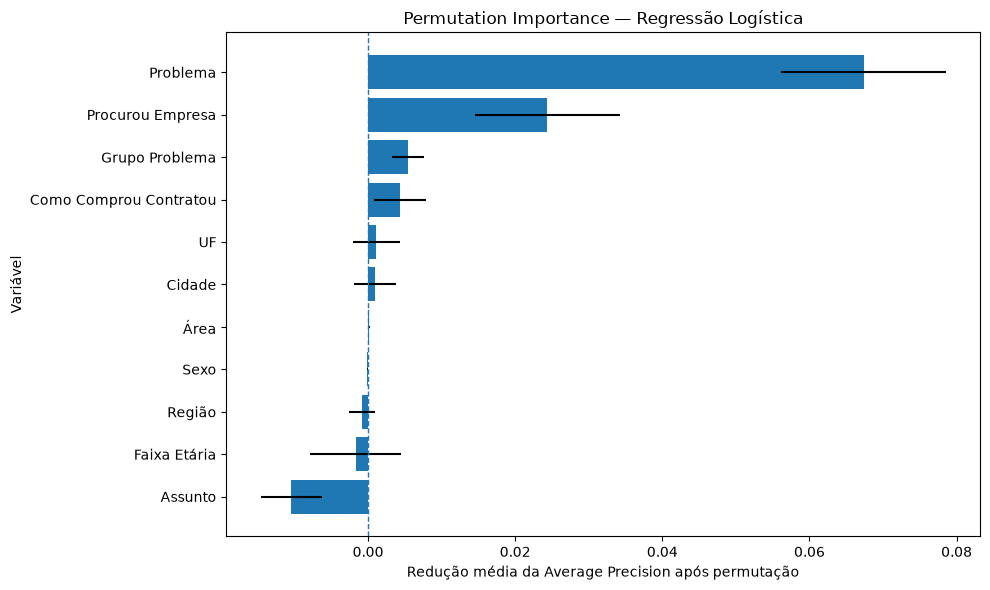

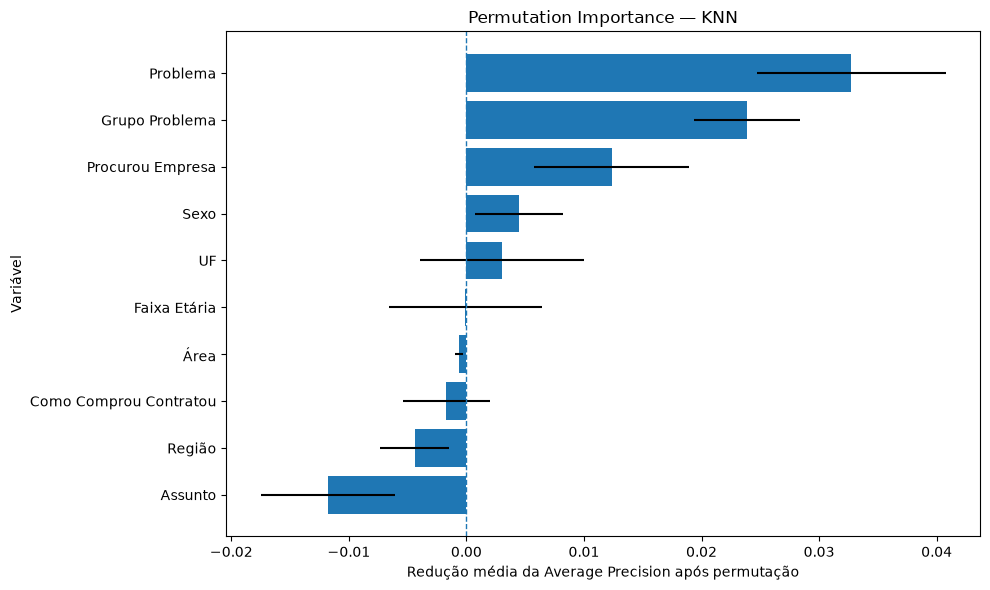

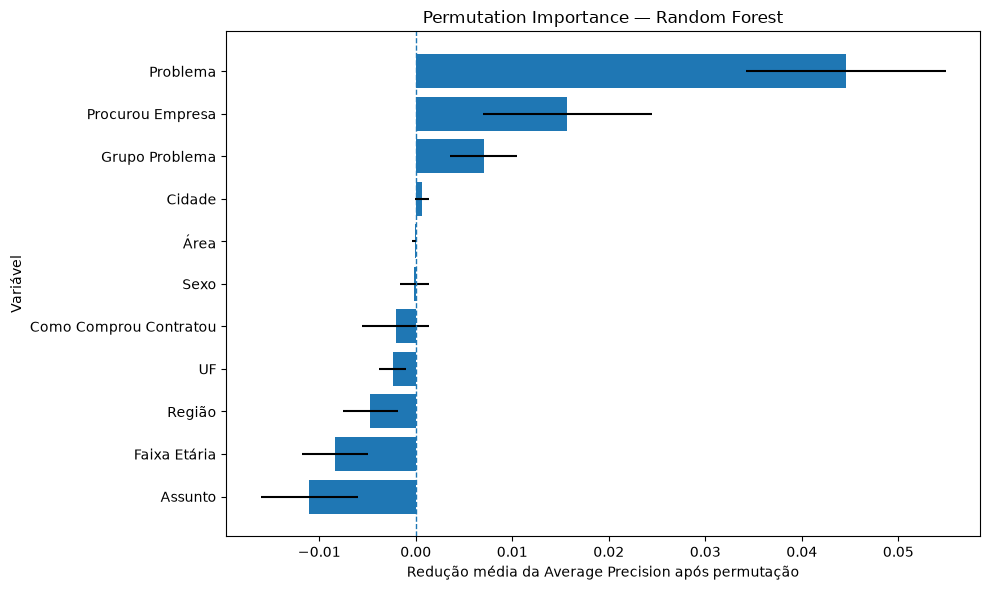

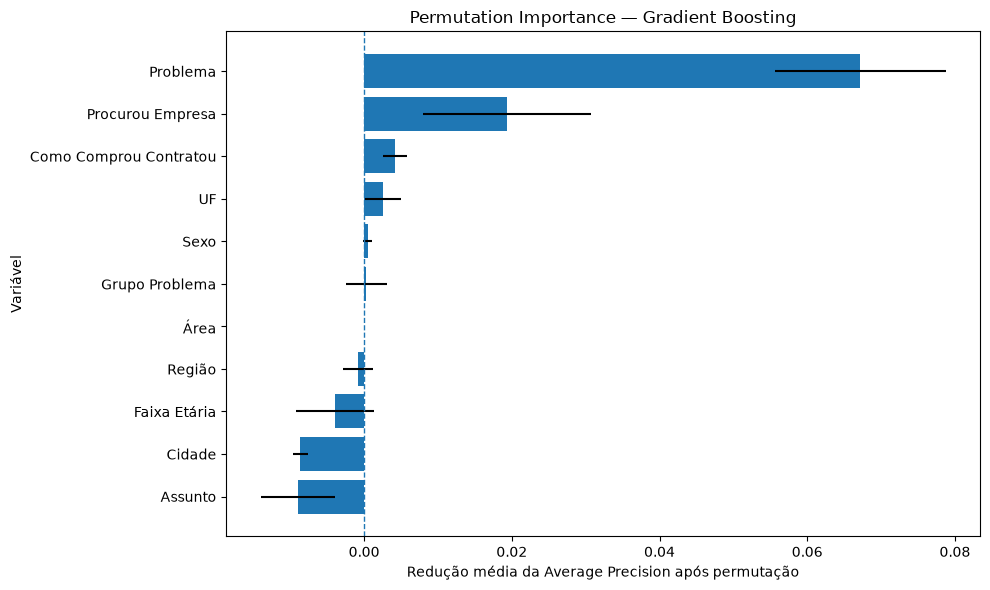

In [8]:
for nome in nomes_modelos:

    dados = (
        permutation_df[
            permutation_df["Modelo"] == nome
        ]
        .sort_values(
            "Importância Média"
        )
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.barh(
        dados["Variável"],
        dados["Importância Média"],
        xerr=dados["Desvio Padrão"]
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"Permutation Importance — {nome}"
    )

    ax.set_xlabel(
        "Redução média da Average Precision após permutação"
    )

    ax.set_ylabel(
        "Variável"
    )

    plt.tight_layout()

    slug = (
        nome.lower()
        .replace(" ", "_")
        .replace("ã", "a")
        .replace("ç", "c")
        .replace("ó", "o")
        .replace("í", "i")
        .replace("é", "e")
    )

    plt.savefig(
        FIGURES_DIR / f"interpretabilidade_permutation_{slug}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


## 9. Comparação dos rankings entre modelos

Esta tabela permite verificar se diferentes algoritmos dependem dos mesmos atributos.

Uma variável importante em vários modelos fornece evidência de **convergência interpretativa**, embora não implique causalidade.


In [9]:
ranking_pivot = (
    permutation_df
    .pivot(
        index="Variável",
        columns="Modelo",
        values="Ranking"
    )
)

ranking_pivot["Ranking médio"] = (
    ranking_pivot.mean(
        axis=1,
        skipna=True
    )
)

ranking_pivot = ranking_pivot.sort_values(
    "Ranking médio"
)

display(
    ranking_pivot.round(2)
)

ranking_pivot.to_csv(
    TABLES_DIR / "interpretabilidade_ranking_comparativo.csv",
    sep=";",
    encoding="utf-8-sig"
)


Modelo,Gradient Boosting,KNN,Random Forest,Regressão Logística,Ranking médio
Variável,,,,,
Problema,1.000000,1.000000,1.000000,1.000000,1.000000
Procurou Empresa,2.000000,3.000000,2.000000,2.000000,2.250000
Grupo Problema,6.000000,2.000000,3.000000,3.000000,3.500000
Como Comprou Contratou,3.000000,8.000000,7.000000,4.000000,5.500000
UF,4.000000,5.000000,8.000000,5.000000,5.500000
Sexo,5.000000,4.000000,6.000000,8.000000,5.750000
Área,7.000000,7.000000,5.000000,7.000000,6.500000
Cidade,10.000000,NaN,4.000000,6.000000,6.670000
Faixa Etária,9.000000,6.000000,10.000000,10.000000,8.750000


## 10. Matriz de importância normalizada

Para facilitar a comparação entre algoritmos, as importâncias positivas são normalizadas dentro de cada modelo.

Valores negativos de Permutation Importance são mantidos como zero nessa visualização comparativa, pois indicam que a perturbação não produziu perda consistente de desempenho.


In [10]:
matriz_importancia = (
    permutation_df
    .pivot(
        index="Variável",
        columns="Modelo",
        values="Importância Média"
    )
    .fillna(0)
)

matriz_normalizada = matriz_importancia.copy()

for coluna in matriz_normalizada.columns:
    valores = (
        matriz_normalizada[coluna]
        .clip(lower=0)
    )

    soma = valores.sum()

    if soma > 0:
        matriz_normalizada[coluna] = (
            valores / soma
        )
    else:
        matriz_normalizada[coluna] = 0

display(
    matriz_normalizada.round(4)
)

matriz_normalizada.to_csv(
    TABLES_DIR / "interpretabilidade_importancia_normalizada.csv",
    sep=";",
    encoding="utf-8-sig"
)


Modelo,Gradient Boosting,KNN,Random Forest,Regressão Logística
Variável,,,,
Assunto,0.000000,0.000000,0.000000,0.000000
Cidade,0.000000,0.000000,0.009700,0.009100
Como Comprou Contratou,0.044000,0.000000,0.000000,0.042000
Faixa Etária,0.000000,0.000000,0.000000,0.000000
Grupo Problema,0.003100,0.311900,0.103700,0.052400
Problema,0.715200,0.428300,0.655500,0.649700
Procurou Empresa,0.206000,0.161800,0.231100,0.235000
Região,0.000000,0.000000,0.000000,0.000000
Sexo,0.004900,0.058700,0.000000,0.000000


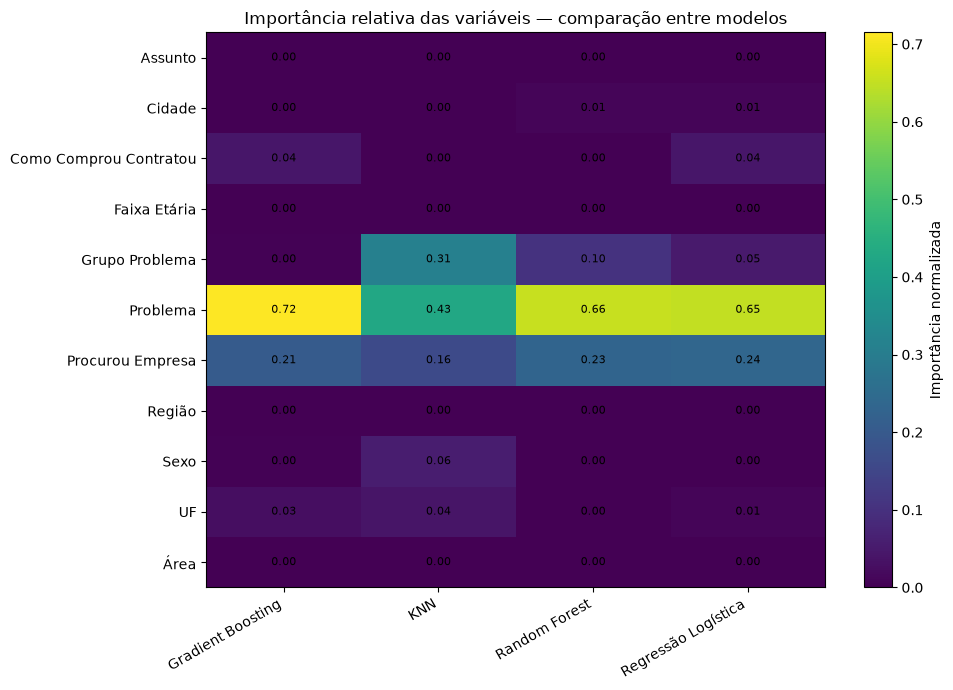

In [11]:
fig, ax = plt.subplots(
    figsize=(10, 7)
)

imagem = ax.imshow(
    matriz_normalizada.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(matriz_normalizada.columns)
    )
)

ax.set_xticklabels(
    matriz_normalizada.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(matriz_normalizada.index)
    )
)

ax.set_yticklabels(
    matriz_normalizada.index
)

for i in range(
    len(matriz_normalizada.index)
):
    for j in range(
        len(matriz_normalizada.columns)
    ):
        ax.text(
            j,
            i,
            f"{matriz_normalizada.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Importância relativa das variáveis — comparação entre modelos"
)

fig.colorbar(
    imagem,
    ax=ax,
    label="Importância normalizada"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "interpretabilidade_importancia_comparativa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PARTE B — Regressão Logística

## 11. Coeficientes das variáveis transformadas

A Regressão Logística permite examinar a direção dos coeficientes.

### Cuidado de interpretação

O modelo foi utilizado com finalidade **preditiva** e regularização.

Portanto:

- os coeficientes representam associações condicionais aprendidas pelo modelo;
- não possuem interpretação causal;
- não serão acompanhados de testes de significância inferencial;
- categorias altamente relacionadas podem compartilhar informação;
- a magnitude deve ser interpretada em conjunto com a representação One-Hot e a regularização.


In [12]:
def obter_transformador_e_estimador(pipeline):
    nomes_steps = list(
        pipeline.named_steps.keys()
    )

    ultimo_nome = nomes_steps[-1]
    estimador = pipeline.named_steps[
        ultimo_nome
    ]

    transformador = pipeline[:-1]

    return transformador, estimador


def obter_nomes_transformados(
    pipeline,
    features_originais
):
    transformador, _ = obter_transformador_e_estimador(
        pipeline
    )

    try:
        nomes = transformador.get_feature_names_out()
        return list(nomes)
    except Exception:
        pass

    for step_name in [
        "preprocessamento",
        "codificacao"
    ]:
        if step_name in pipeline.named_steps:
            step = pipeline.named_steps[
                step_name
            ]

            if hasattr(
                step,
                "get_feature_names_out"
            ):
                try:
                    return list(
                        step.get_feature_names_out()
                    )
                except Exception:
                    pass

    return [
        f"feature_{i}"
        for i in range(
            len(features_originais)
        )
    ]


if "Regressão Logística" not in modelos:
    print(
        "Regressão Logística não está entre os modelos avaliados."
    )
else:
    modelo_lr = modelos[
        "Regressão Logística"
    ]

    features_lr = features_por_modelo[
        "Regressão Logística"
    ]

    _, estimador_lr = obter_transformador_e_estimador(
        modelo_lr
    )

    nomes_transformados_lr = obter_nomes_transformados(
        modelo_lr,
        features_lr
    )

    coeficientes = (
        np.asarray(
            estimador_lr.coef_
        )
        .ravel()
    )

    if len(nomes_transformados_lr) != len(coeficientes):
        nomes_transformados_lr = [
            f"feature_{i}"
            for i in range(
                len(coeficientes)
            )
        ]

    tabela_coef = pd.DataFrame({
        "Feature transformada": nomes_transformados_lr,
        "Coeficiente": coeficientes,
        "Exp(Coeficiente)": np.exp(
            np.clip(
                coeficientes,
                -20,
                20
            )
        )
    })

    tabela_coef["Magnitude"] = (
        tabela_coef["Coeficiente"]
        .abs()
    )

    tabela_coef = (
        tabela_coef
        .sort_values(
            "Magnitude",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        tabela_coef.head(40).round(6)
    )

    tabela_coef.to_csv(
        TABLES_DIR / "interpretabilidade_coeficientes_reglog.csv",
        sep=";",
        encoding="utf-8-sig",
        index=False
    )


,Feature transformada,Coeficiente,Exp(Coeficiente),Magnitude
0,cat__Problema_SAC - Dificuldade para cancelar o serviço,0.807539,2.242383,0.807539
1,cat__Problema_Não entrega do contrato ou documentação relacionada ao serviço,0.727437,2.069769,0.727437
2,cat__Assunto_Crédito Rural,-0.638424,0.528124,0.638424
3,cat__Cidade_Boqueirão do Piauí,-0.637783,0.528463,0.637783
4,cat__Problema_Dificuldade para rescindir o contrato / cancelar o serviço,0.600077,1.822259,0.600077
5,"cat__Problema_Clonagem, fraude, furto e roubo",-0.574061,0.563234,0.574061
6,"cat__Problema_Cálculo de juros, saldo devedor (contestação, solicitação de histórico, dúvidas)",-0.568138,0.566579,0.568138
7,cat__Problema_Renegociação / parcelamento de dívida,-0.565108,0.568299,0.565108
8,cat__Assunto_Demais Seguros,0.541336,1.718302,0.541336
9,cat__Cidade_Araguaína,-0.528381,0.589559,0.528381


## 12. Maiores coeficientes positivos e negativos


In [13]:
if "Regressão Logística" in modelos:

    positivos_lr = (
        tabela_coef
        .sort_values(
            "Coeficiente",
            ascending=False
        )
        .head(20)
    )

    negativos_lr = (
        tabela_coef
        .sort_values(
            "Coeficiente",
            ascending=True
        )
        .head(20)
    )

    print(
        "Maiores coeficientes associados à classe Resolvida"
    )

    display(
        positivos_lr[
            [
                "Feature transformada",
                "Coeficiente",
                "Exp(Coeficiente)"
            ]
        ].round(6)
    )

    print()
    print(
        "Maiores coeficientes associados à classe Não Resolvida"
    )

    display(
        negativos_lr[
            [
                "Feature transformada",
                "Coeficiente",
                "Exp(Coeficiente)"
            ]
        ].round(6)
    )


Maiores coeficientes associados à classe Resolvida


,Feature transformada,Coeficiente,Exp(Coeficiente)
0,cat__Problema_SAC - Dificuldade para cancelar o serviço,0.807539,2.242383
1,cat__Problema_Não entrega do contrato ou documentação relacionada ao serviço,0.727437,2.069769
4,cat__Problema_Dificuldade para rescindir o contrato / cancelar o serviço,0.600077,1.822259
8,cat__Assunto_Demais Seguros,0.541336,1.718302
13,cat__Problema_Negativação indevida referente à pagamento já efetuado,0.476525,1.610469
16,cat__Problema_Cobrança em duplicidade / Cobrança referente a pagamento já efetuado,0.465490,1.592795
18,cat__Cidade_Piracicaba,0.452153,1.571692
19,cat__Problema_Dificuldade para alterar ou cancelar o contrato /serviço,0.430287,1.537699
21,"cat__Problema_Dificuldade para obter boleto de quitação ou informações acerca de cálculos, pagamentos, saldo devedor",0.378806,1.460539
23,cat__Faixa Etária_entre 21 a 30 anos,0.355115,1.426344



Maiores coeficientes associados à classe Não Resolvida


,Feature transformada,Coeficiente,Exp(Coeficiente)
2,cat__Assunto_Crédito Rural,-0.638424,0.528124
3,cat__Cidade_Boqueirão do Piauí,-0.637783,0.528463
5,"cat__Problema_Clonagem, fraude, furto e roubo",-0.574061,0.563234
6,"cat__Problema_Cálculo de juros, saldo devedor (contestação, solicitação de histórico, dúvidas)",-0.568138,0.566579
7,cat__Problema_Renegociação / parcelamento de dívida,-0.565108,0.568299
9,cat__Cidade_Araguaína,-0.528381,0.589559
10,cat__Problema_Alteração / rescisão de contrato sem solicitação / aviso prévio,-0.523419,0.592492
11,cat__Problema_Negativação indevida referente a cobrança não reconhecida,-0.522921,0.592786
12,cat__Problema_Dificuldade para contratar / recusa injustificada,-0.493334,0.610587
14,cat__Assunto_Crédito Consignado / Cartão de Crédito Consignado / RMC (para beneficiários do INSS),-0.476327,0.621060


# PARTE C — Importâncias internas dos modelos de árvore

## 13. Agregação das importâncias por variável original

Random Forest e Gradient Boosting fornecem `feature_importances_` após o One-Hot Encoding.

Como uma variável original pode gerar muitas dummies, as importâncias serão **somadas por variável original**.

Essa medida será comparada posteriormente com a Permutation Importance.


In [14]:
def limpar_nome_transformado(nome):
    nome = str(nome)

    if "__" in nome:
        nome = nome.split(
            "__",
            1
        )[1]

    return nome


def identificar_variavel_original(
    nome_transformado,
    variaveis_originais
):
    nome_limpo = limpar_nome_transformado(
        nome_transformado
    )

    # Maior nome primeiro para evitar correspondências parciais
    for variavel in sorted(
        variaveis_originais,
        key=len,
        reverse=True
    ):
        if (
            nome_limpo == variavel
            or nome_limpo.startswith(
                variavel + "_"
            )
        ):
            return variavel

    return "Não identificada"


linhas_arvores = []

for nome in [
    "Random Forest",
    "Gradient Boosting"
]:
    if nome not in modelos:
        continue

    pipeline = modelos[nome]
    features_originais = features_por_modelo[
        nome
    ]

    _, estimador = obter_transformador_e_estimador(
        pipeline
    )

    if not hasattr(
        estimador,
        "feature_importances_"
    ):
        print(
            f"{nome}: estimador sem feature_importances_."
        )
        continue

    importancias = np.asarray(
        estimador.feature_importances_
    )

    nomes_transformados = obter_nomes_transformados(
        pipeline,
        features_originais
    )

    if len(nomes_transformados) != len(importancias):
        nomes_transformados = [
            f"feature_{i}"
            for i in range(
                len(importancias)
            )
        ]

    detalhe = pd.DataFrame({
        "Feature transformada": nomes_transformados,
        "Importância": importancias
    })

    detalhe["Variável original"] = (
        detalhe["Feature transformada"]
        .apply(
            lambda x:
            identificar_variavel_original(
                x,
                features_originais
            )
        )
    )

    agregado = (
        detalhe
        .groupby(
            "Variável original",
            as_index=False
        )["Importância"]
        .sum()
        .sort_values(
            "Importância",
            ascending=False
        )
    )

    agregado["Modelo"] = nome

    linhas_arvores.append(
        agregado
    )

    print()
    print(nome)

    display(
        agregado[
            [
                "Variável original",
                "Importância"
            ]
        ].round(6)
    )

if linhas_arvores:
    importancias_arvores = pd.concat(
        linhas_arvores,
        ignore_index=True
    )

    importancias_arvores.to_csv(
        TABLES_DIR / "interpretabilidade_importancias_arvores.csv",
        sep=";",
        encoding="utf-8-sig",
        index=False
    )
else:
    importancias_arvores = pd.DataFrame()



Random Forest


,Variável original,Importância
5,Problema,0.304310
0,Assunto,0.111999
4,Grupo Problema,0.108329
9,UF,0.099554
1,Cidade,0.093427
3,Faixa Etária,0.088103
2,Como Comprou Contratou,0.062658
6,Procurou Empresa,0.049960
7,Região,0.048515
8,Sexo,0.028276



Gradient Boosting


,Variável original,Importância
5,Problema,0.455529
4,Grupo Problema,0.119268
3,Faixa Etária,0.097439
0,Assunto,0.083712
6,Procurou Empresa,0.079311
1,Cidade,0.074019
2,Como Comprou Contratou,0.030963
9,UF,0.028569
7,Região,0.028481
8,Sexo,0.002279


# PARTE D — SHAP para modelos de árvore

## 14. Análise SHAP opcional

SHAP será utilizado somente como complemento para Random Forest e Gradient Boosting.

Para reduzir custo computacional:

- é utilizada uma amostra reproduzível do OOT;
- os dados são transformados pelo pipeline já congelado;
- os valores absolutos médios de SHAP são agregados por variável original.

Caso a biblioteca `shap` não esteja instalada, esta seção será ignorada sem impedir o restante do notebook.


In [15]:
SHAP_DISPONIVEL = (
    importlib.util.find_spec(
        "shap"
    )
    is not None
)

print(
    f"SHAP disponível: {SHAP_DISPONIVEL}"
)

if EXECUTAR_SHAP and not SHAP_DISPONIVEL:
    print(
        "A biblioteca shap não está instalada. "
        "As demais análises continuam válidas."
    )


SHAP disponível: True


In [16]:
shap_agregado = pd.DataFrame()

if EXECUTAR_SHAP and SHAP_DISPONIVEL:

    import shap

    n_shap = min(
        N_AMOSTRA_SHAP,
        len(df_oot)
    )

    _, df_shap = train_test_split(
        df_oot,
        test_size=n_shap,
        stratify=df_oot[TARGET],
        random_state=RANDOM_STATE
    )

    resultados_shap = []

    for nome in [
        "Random Forest",
        "Gradient Boosting"
    ]:
        if nome not in modelos:
            continue

        print()
        print("=" * 80)
        print(f"SHAP — {nome}")
        print("=" * 80)

        pipeline = modelos[nome]
        features_originais = features_por_modelo[
            nome
        ]

        transformador, estimador = (
            obter_transformador_e_estimador(
                pipeline
            )
        )

        X_raw = df_shap[
            features_originais
        ].copy()

        X_trans = transformador.transform(
            X_raw
        )

        if hasattr(
            X_trans,
            "toarray"
        ):
            X_trans = X_trans.toarray()

        X_trans = np.asarray(
            X_trans
        )

        nomes_transformados = (
            obter_nomes_transformados(
                pipeline,
                features_originais
            )
        )

        if (
            len(nomes_transformados)
            != X_trans.shape[1]
        ):
            nomes_transformados = [
                f"feature_{i}"
                for i in range(
                    X_trans.shape[1]
                )
            ]

        explainer = shap.TreeExplainer(
            estimador
        )

        valores = explainer.shap_values(
            X_trans
        )

        if isinstance(
            valores,
            list
        ):
            if len(valores) >= 2:
                valores = valores[1]
            else:
                valores = valores[0]

        valores = np.asarray(
            valores
        )

        if valores.ndim == 3:
            if valores.shape[-1] >= 2:
                valores = valores[:, :, 1]
            elif valores.shape[0] >= 2:
                valores = valores[1]

        importancia_shap = np.mean(
            np.abs(valores),
            axis=0
        )

        detalhe_shap = pd.DataFrame({
            "Feature transformada": nomes_transformados,
            "Mean |SHAP|": importancia_shap
        })

        detalhe_shap["Variável original"] = (
            detalhe_shap[
                "Feature transformada"
            ]
            .apply(
                lambda x:
                identificar_variavel_original(
                    x,
                    features_originais
                )
            )
        )

        agregado_shap = (
            detalhe_shap
            .groupby(
                "Variável original",
                as_index=False
            )["Mean |SHAP|"]
            .sum()
            .sort_values(
                "Mean |SHAP|",
                ascending=False
            )
        )

        agregado_shap["Modelo"] = nome

        resultados_shap.append(
            agregado_shap
        )

        display(
            agregado_shap[
                [
                    "Variável original",
                    "Mean |SHAP|"
                ]
            ].round(6)
        )

    if resultados_shap:
        shap_agregado = pd.concat(
            resultados_shap,
            ignore_index=True
        )

        shap_agregado.to_csv(
            TABLES_DIR / "interpretabilidade_shap_agregado.csv",
            sep=";",
            encoding="utf-8-sig",
            index=False
        )



SHAP — Random Forest


,Variável original,Mean |SHAP|
5,Problema,0.091149
4,Grupo Problema,0.041261
0,Assunto,0.033636
3,Faixa Etária,0.033613
6,Procurou Empresa,0.030195
9,UF,0.014494
2,Como Comprou Contratou,0.013008
7,Região,0.011476
1,Cidade,0.008682
8,Sexo,0.005270



SHAP — Gradient Boosting


,Variável original,Mean |SHAP|
5,Problema,0.507395
3,Faixa Etária,0.186612
4,Grupo Problema,0.140136
6,Procurou Empresa,0.138986
0,Assunto,0.117494
7,Região,0.060088
2,Como Comprou Contratou,0.056604
1,Cidade,0.026731
9,UF,0.021353
8,Sexo,0.002018


# PARTE E — Convergência entre métodos

## 15. Permutation Importance × importância interna das árvores

A comparação abaixo verifica se as variáveis consideradas importantes pela estrutura interna dos modelos também produzem perda de desempenho quando são perturbadas.


In [17]:
comparacao_metodos = []

if not importancias_arvores.empty:

    for nome in [
        "Random Forest",
        "Gradient Boosting"
    ]:
        if nome not in modelos:
            continue

        perm = (
            permutation_df[
                permutation_df["Modelo"] == nome
            ][
                [
                    "Variável",
                    "Importância Média"
                ]
            ]
            .rename(
                columns={
                    "Variável": "Variável original",
                    "Importância Média":
                    "Permutation Importance"
                }
            )
        )

        interna = (
            importancias_arvores[
                importancias_arvores[
                    "Modelo"
                ] == nome
            ][
                [
                    "Variável original",
                    "Importância"
                ]
            ]
            .rename(
                columns={
                    "Importância":
                    "Importância interna"
                }
            )
        )

        comp = perm.merge(
            interna,
            on="Variável original",
            how="outer"
        )

        comp["Modelo"] = nome

        comparacao_metodos.append(
            comp
        )

if comparacao_metodos:
    comparacao_metodos_df = pd.concat(
        comparacao_metodos,
        ignore_index=True
    )

    display(
        comparacao_metodos_df
        .sort_values(
            [
                "Modelo",
                "Permutation Importance"
            ],
            ascending=[
                True,
                False
            ]
        )
        .round(6)
    )

    comparacao_metodos_df.to_csv(
        TABLES_DIR / "interpretabilidade_comparacao_metodos.csv",
        sep=";",
        encoding="utf-8-sig",
        index=False
    )
else:
    comparacao_metodos_df = pd.DataFrame()


,Variável original,Permutation Importance,Importância interna,Modelo
16,Problema,0.067182,0.455529,Gradient Boosting
17,Procurou Empresa,0.019351,0.079311,Gradient Boosting
13,Como Comprou Contratou,0.004137,0.030963,Gradient Boosting
20,UF,0.002509,0.028569,Gradient Boosting
19,Sexo,0.000464,0.002279,Gradient Boosting
15,Grupo Problema,0.000293,0.119268,Gradient Boosting
21,Área,0.000005,0.000430,Gradient Boosting
18,Região,-0.000837,0.028481,Gradient Boosting
14,Faixa Etária,-0.003938,0.097439,Gradient Boosting
12,Cidade,-0.008619,0.074019,Gradient Boosting


## 16. Consenso de importância entre os modelos

A tabela abaixo resume:

- número de modelos nos quais a variável aparece entre as três mais importantes por Permutation Importance;
- ranking médio entre os modelos;
- importância média normalizada.

Isso não produz uma classificação de "melhores variáveis"; serve apenas para mostrar **convergência ou divergência entre os algoritmos**.


In [18]:
resumo_variaveis = []

for variavel in PREDITORES_PADRAO:

    temp = permutation_df[
        permutation_df[
            "Variável"
        ] == variavel
    ]

    if temp.empty:
        continue

    top3 = int(
        (temp["Ranking"] <= 3)
        .sum()
    )

    importancia_norm = (
        matriz_normalizada
        .loc[
            variavel
        ]
        .mean()
        if variavel in
        matriz_normalizada.index
        else np.nan
    )

    resumo_variaveis.append({
        "Variável": variavel,
        "Modelos no Top 3": top3,
        "Ranking médio": temp["Ranking"].mean(),
        "Importância normalizada média":
            importancia_norm
    })

consenso_variaveis = (
    pd.DataFrame(
        resumo_variaveis
    )
    .sort_values(
        [
            "Modelos no Top 3",
            "Ranking médio"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    consenso_variaveis.round(4)
)

consenso_variaveis.to_csv(
    TABLES_DIR / "interpretabilidade_consenso_variaveis.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Variável,Modelos no Top 3,Ranking médio,Importância normalizada média
0,Problema,4,1.000000,0.612200
1,Procurou Empresa,4,2.250000,0.208500
2,Grupo Problema,3,3.500000,0.117800
3,Como Comprou Contratou,1,5.500000,0.021500
4,UF,0,5.500000,0.019200
5,Sexo,0,5.750000,0.015900
6,Área,0,6.500000,0.000300
7,Cidade,0,6.666700,0.004700
8,Região,0,8.750000,0.000000
9,Faixa Etária,0,8.750000,0.000000


# PARTE F — Perfil do grupo operacional priorizado

## 17. Aplicação da regra operacional congelada no OOT

Esta seção não altera a regra definida anteriormente.

Ela apenas descreve, para cada modelo, quais registros compõem o grupo priorizado no OOT.


In [19]:
ESTRATEGIA = configuracao["estrategia_operacional"]
TOP_K = configuracao.get(
    "top_k_percentual"
)
THRESHOLD = configuracao.get(
    "threshold_operacional"
)

grupos_priorizados = {}

for nome, modelo in modelos.items():

    features = features_por_modelo[
        nome
    ]

    prob = modelo.predict_proba(
        df_oot[features]
    )[:, 1]

    if ESTRATEGIA == "top_k":

        n_top = int(
            np.ceil(
                len(df_oot) *
                float(TOP_K) /
                100
            )
        )

        indices_ordem = np.argsort(
            -prob
        )

        mascara = np.zeros(
            len(df_oot),
            dtype=bool
        )

        mascara[
            indices_ordem[:n_top]
        ] = True

    elif ESTRATEGIA == "threshold":

        mascara = (
            prob >=
            float(THRESHOLD)
        )

    else:
        raise ValueError(
            f"Estratégia desconhecida: {ESTRATEGIA}"
        )

    grupo = df_oot.loc[
        mascara
    ].copy()

    grupos_priorizados[nome] = grupo

    print(
        f"{nome}: "
        f"{len(grupo):,} priorizadas "
        f"({len(grupo)/len(df_oot)*100:.2f}%)"
    )


Regressão Logística: 3,464 priorizadas (10.80%)
KNN: 3,119 priorizadas (9.72%)
Random Forest: 1,682 priorizadas (5.24%)
Gradient Boosting: 2,187 priorizadas (6.82%)


## 18. Variáveis com maior mudança de composição no grupo priorizado

Para evitar tabelas excessivamente extensas, é calculado o **Total Variation Distance (TVD)** entre:

- distribuição da variável em todo o OOT;
- distribuição da mesma variável no grupo priorizado pelo modelo.

Quanto maior o TVD, maior a diferença de composição entre o grupo priorizado e a população OOT.


In [20]:
def tvd_categorico(
    total,
    grupo
):
    p = (
        total.fillna(
            "__MISSING__"
        )
        .astype(str)
        .value_counts(
            normalize=True
        )
    )

    q = (
        grupo.fillna(
            "__MISSING__"
        )
        .astype(str)
        .value_counts(
            normalize=True
        )
    )

    categorias = p.index.union(
        q.index
    )

    p = p.reindex(
        categorias,
        fill_value=0
    )

    q = q.reindex(
        categorias,
        fill_value=0
    )

    return float(
        0.5 *
        np.abs(
            p - q
        ).sum()
    )


linhas_tvd = []

for nome, grupo in grupos_priorizados.items():

    for variavel in features_por_modelo[
        nome
    ]:

        linhas_tvd.append({
            "Modelo": nome,
            "Variável": variavel,
            "TVD": tvd_categorico(
                df_oot[variavel],
                grupo[variavel]
            )
        })

tvd_operacional = (
    pd.DataFrame(
        linhas_tvd
    )
    .sort_values(
        [
            "Modelo",
            "TVD"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    tvd_operacional.round(4)
)

tvd_operacional.to_csv(
    TABLES_DIR / "interpretabilidade_tvd_grupo_priorizado.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Variável,TVD
0,Gradient Boosting,Problema,0.655900
1,Gradient Boosting,Grupo Problema,0.458500
2,Gradient Boosting,Cidade,0.374200
3,Gradient Boosting,Procurou Empresa,0.328900
4,Gradient Boosting,Assunto,0.175600
5,Gradient Boosting,Faixa Etária,0.168200
6,Gradient Boosting,UF,0.116200
7,Gradient Boosting,Região,0.093900
8,Gradient Boosting,Como Comprou Contratou,0.085200
9,Gradient Boosting,Sexo,0.052400


# PARTE G — Síntese para Resultados e Discussões

## 19. Síntese automática


In [21]:
print("=" * 80)
print("PERMUTATION IMPORTANCE — TRÊS PRINCIPAIS VARIÁVEIS POR MODELO")
print("=" * 80)

for nome in nomes_modelos:

    temp = (
        permutation_df[
            permutation_df[
                "Modelo"
            ] == nome
        ]
        .sort_values(
            "Ranking"
        )
        .head(3)
    )

    print()
    print(nome)

    for _, linha in temp.iterrows():
        print(
            f"- {linha['Variável']}: "
            f"importância = "
            f"{linha['Importância Média']:.6f} "
            f"(± {linha['Desvio Padrão']:.6f})"
        )

print()
print("=" * 80)
print("CONVERGÊNCIA ENTRE MODELOS")
print("=" * 80)

for _, linha in consenso_variaveis.head(5).iterrows():
    print(
        f"- {linha['Variável']}: "
        f"Top 3 em {int(linha['Modelos no Top 3'])} modelo(s); "
        f"ranking médio = {linha['Ranking médio']:.2f}."
    )

print()
print("=" * 80)
print("PERFIL OPERACIONAL — MAIORES TVD")
print("=" * 80)

for nome in nomes_modelos:

    temp = (
        tvd_operacional[
            tvd_operacional[
                "Modelo"
            ] == nome
        ]
        .head(3)
    )

    print()
    print(nome)

    for _, linha in temp.iterrows():
        print(
            f"- {linha['Variável']}: "
            f"TVD = {linha['TVD']:.4f}"
        )

print()
print(
    "As medidas de interpretabilidade devem ser lidas como descrições "
    "do comportamento dos modelos congelados. Não constituem evidência "
    "causal nem serão utilizadas para reabrir o desenvolvimento após o OOT."
)


PERMUTATION IMPORTANCE — TRÊS PRINCIPAIS VARIÁVEIS POR MODELO

Regressão Logística
- Problema: importância = 0.067357 (± 0.011166)
- Procurou Empresa: importância = 0.024368 (± 0.009900)
- Grupo Problema: importância = 0.005428 (± 0.002187)

KNN
- Problema: importância = 0.032754 (± 0.008018)
- Grupo Problema: importância = 0.023851 (± 0.004492)
- Procurou Empresa: importância = 0.012374 (± 0.006592)

Random Forest
- Problema: importância = 0.044561 (± 0.010349)
- Procurou Empresa: importância = 0.015710 (± 0.008780)
- Grupo Problema: importância = 0.007052 (± 0.003461)

Gradient Boosting
- Problema: importância = 0.067182 (± 0.011572)
- Procurou Empresa: importância = 0.019351 (± 0.011424)
- Como Comprou Contratou: importância = 0.004137 (± 0.001607)

CONVERGÊNCIA ENTRE MODELOS
- Problema: Top 3 em 4 modelo(s); ranking médio = 1.00.
- Procurou Empresa: Top 3 em 4 modelo(s); ranking médio = 2.25.
- Grupo Problema: Top 3 em 3 modelo(s); ranking médio = 3.50.
- Como Comprou Contratou: To

## 20. Arquivos produzidos

### Tabelas

- `interpretabilidade_permutation_importance.csv`
- `interpretabilidade_ranking_comparativo.csv`
- `interpretabilidade_importancia_normalizada.csv`
- `interpretabilidade_coeficientes_reglog.csv`
- `interpretabilidade_importancias_arvores.csv`
- `interpretabilidade_shap_agregado.csv` — quando SHAP estiver disponível
- `interpretabilidade_comparacao_metodos.csv`
- `interpretabilidade_consenso_variaveis.csv`
- `interpretabilidade_tvd_grupo_priorizado.csv`

### Figuras

- Permutation Importance por modelo;
- matriz comparativa das importâncias normalizadas.

## Próxima etapa

Após a interpretação dos resultados deste notebook:

**10 — Síntese Multidimensional dos Modelos**

A etapa final deverá integrar:

1. desempenho classificatório;
2. discriminação;
3. desempenho operacional;
4. generalização OOT;
5. calibração;
6. estabilidade temporal;
7. interpretabilidade.

A conclusão não deverá ser baseada em uma única métrica.
